## Estimador de producción de entropía en un sistema de Ornstein-Uhlenbeck

In [1]:
import sys

sys.path.append('..')

In [2]:
from argparse import Namespace

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy import stats
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
from muestras import muestra
from ornstein_uhlenbeck import simulacion, dif_entropia_medio, dif_entropia_shannon
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

### Estimador

In [3]:
class estimador(nn.Module):
    def __init__(self, hp):
        super(estimador, self).__init__()
        self.h = nn.Sequential(
            nn.Linear(2*hp.n_entrada, hp.n_ocultas),
            nn.ReLU(inplace=True),
            nn.Linear(hp.n_ocultas, hp.n_ocultas),
            nn.ReLU(inplace=True),
            nn.Linear(hp.n_ocultas, hp.n_ocultas),
            nn.ReLU(inplace=True),
            nn.Linear(hp.n_ocultas, 2)
        )

    def forward(self, s1, s2):
        x = torch.cat([s1, s2], dim=-1)
        x_ = torch.cat([s2, s1], dim=-1)
        
        salida = self.h(x) - self.h(x_)
        media = salida[:, 0].unsqueeze(-1)
        log_desviacion_estandar = salida[:, 1].unsqueeze(-1)
        
        return media, log_desviacion_estandar

### Algoritmo de entrenamiento

In [4]:
def entrenar(hp, modelo, optimizador, trayectorias, muestra_):
    modelo.train()
    turno, turno_siguiente = next(muestra_)
    
    s_ant = trayectorias[turno].to(hp.procesamiento)
    s_sig = trayectorias[turno_siguiente].to(hp.procesamiento)
    produccion_entropia, log_sigma = modelo(s_ant, s_sig)

    optimizador.zero_grad()
    
    # Función objetivo
    J = (-produccion_entropia + torch.exp(-produccion_entropia)).mean()
    log_verosimilitud = -((-0.5 * torch.log(2 * torch.pi * torch.exp(log_sigma)**2) - 0.5 * ((s_sig - produccion_entropia)**2 / torch.exp(log_sigma)**2)).sum(dim=-1)).mean()
    perdida = J * log_verosimilitud
    
    perdida.backward()
    optimizador.step()
    return perdida.item()

def validar(hp, modelo, trayectorias, muestra_):
    modelo.eval()

    ret = []
    perdida = 0
    with torch.no_grad():
        for turno, turno_siguiente in muestra_:
            s_ant = trayectorias[turno].to(hp.procesamiento)
            s_sig = trayectorias[turno_siguiente].to(hp.procesamiento)
            
            produccion_entropia, _ = modelo(s_ant, s_sig)
            entropia = produccion_entropia.cpu().squeeze().numpy()
            ret.append(entropia)
            perdida += (-produccion_entropia + torch.exp(-produccion_entropia)).sum().cpu().item()
    perdida = perdida / muestra_.tamaño
    ret = np.concatenate(ret)
    ret = ret.reshape(trayectorias.shape[0], trayectorias.shape[1]-1)
    return ret, perdida

### Hiperparámetros

In [5]:
hp = Namespace()
hp.procesamiento = 'cpu' 
hp.tamaño_entrada = 2048
hp.tamaño_entrada_prueba = 25000
hp.n_entrada = 2
hp.n_ocultas = 256

hp.lr = 0.0001
hp.wd = 5e-5

hp.record_freq = 1000
hp.seed = np.random.randint(0, 100)

torch.manual_seed(hp.seed)

## Trayectorias

In [6]:
hp.M = 100           # numero de trayectorias
hp.L = 1000          # longitud de una trayectoria
hp.n_libertad = 2    # número de grados de libertad
hp.Tf = 1            # temperature fría
hp.Tc = 10           # temperature caliente
hp.time_step = 0.01  # tamaño del paso de tiempo

trayectorias = simulacion(hp.M, hp.L, hp.n_libertad, hp.Tf, hp.Tc, hp.time_step, seed=0)
trayectorias_prueba = simulacion(hp.M, hp.L, hp.n_libertad, hp.Tf, hp.Tc, hp.time_step, seed=1)

trayectorias_t = trayectorias.to(hp.procesamiento).float()
trayectorias_prueba_t = trayectorias_prueba.to(hp.procesamiento).float()

## Entrenamiento

In [7]:
modelo = estimador(hp)
modelo = modelo.to(hp.procesamiento)
optimizador = torch.optim.Adam(modelo.parameters(), hp.lr, weight_decay=hp.wd)

muestra_entrenamiento = muestra(hp.M, hp.L, hp.tamaño_entrada, procesamiento=hp.procesamiento)
muestra_prueba = muestra(hp.M, hp.L, hp.tamaño_entrada_prueba, procesamiento=hp.procesamiento, entrenar=False)

# Salidas antes de comenzar el entrenamiento
salida_inicial, _ = validar(hp, modelo, trayectorias_prueba_t, muestra_prueba)

# Producción de entropía analítica
entropia=dif_entropia_medio(trayectorias_prueba[:100],hp.Tf,hp.Tc)+dif_entropia_shannon(trayectorias_prueba[:100],hp.Tf,hp.Tc)

In [8]:
def plot_scatter(salida_, entropia_):
    salida_rate, _, r_value, pvalue, _  = stats.linregress(entropia_, salida_)
    plt.figure(figsize=(4,4), dpi=100)
    sns.regplot(x=entropia_, y=salida_,
                color='r', 
                line_kws={
                    'lw':1.5,
                    'label':'$R^2=%.4f$ p-value: %.4f' %(r_value**2, pvalue)},
                scatter_kws={
                    'color':'k', 
                    'alpha':0.3, 
                    's':3, 
                    'rasterized':True})
    plt.xlabel('$\Delta S$', fontsize=12)
    plt.ylabel('$\Delta S_{\\theta}$', fontsize=12)
    plt.legend()

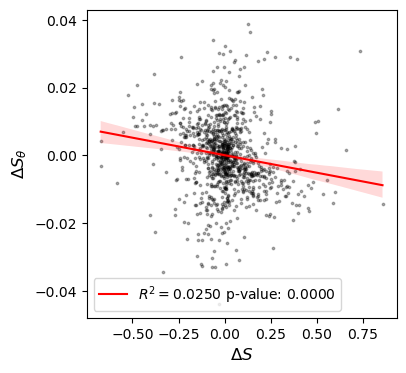

In [9]:
indice = np.random.randint(0, 100)
salida_ = salida_inicial[indice]
entropia_ = entropia[indice]
plot_scatter(salida_, entropia_.numpy())

In [10]:
hp.n_iteraciones = 1000 # número de iteraciones de entrenamiento

for i in tqdm(range(1, hp.n_iteraciones + 1)):
    entrenar(hp, modelo, optimizador, trayectorias_t, muestra_entrenamiento)

  0%|          | 0/1000 [00:00<?, ?it/s]

### Prueba

In [11]:
salida, _ = validar(hp, modelo, trayectorias_prueba_t, muestra_prueba)

# Producción de entropía analítica
entropia=dif_entropia_medio(trayectorias_prueba[:100],hp.Tf,hp.Tc)+dif_entropia_shannon(trayectorias_prueba[:100],hp.Tf,hp.Tc)

## Resultados
### Producción de entropía

{torch.Size([100, 999])}

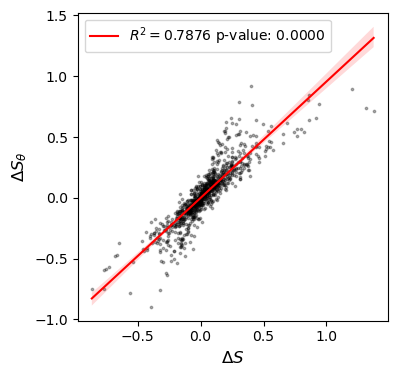

In [12]:
indice = np.random.randint(0, 100)
entropia_ = entropia[indice]
salida_ = salida[indice]
plot_scatter(salida_, entropia_.numpy())
{entropia.shape, salida.shape}

### Producción de entropía de una trayectoria

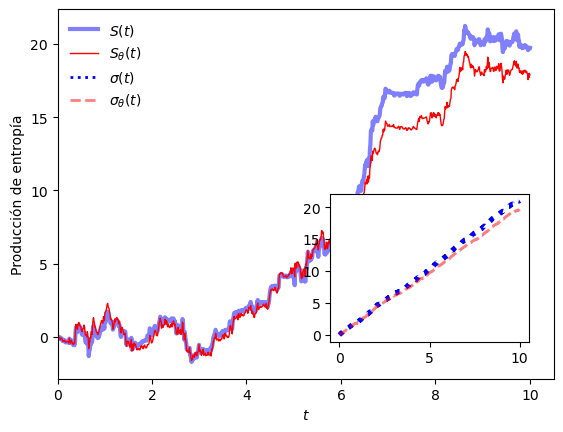

In [13]:
indice = np.random.randint(0, 100)
entropia_ = entropia[indice]
salida_ = salida[indice]

salida_c = np.cumsum(salida, axis=1)
entropia_c = np.cumsum(entropia, axis=1)

ts = np.linspace(0, hp.L * hp.time_step, num=hp.L - 1)

plt.figure(dpi=100)
plt.plot(ts, np.cumsum(entropia_), lw=3, alpha=0.5,color='b', 
         label='$S(t)$')
plt.plot(ts, np.cumsum(salida_), lw=1, color='r',
         label='$S_{\\theta}(t)$')
plt.plot([], ls = 'dotted', color='b', lw=2, 
         label='$\sigma(t)$')
plt.plot([], lw=2, ls = '--', alpha=0.5, color='r',
         label='$\sigma_{\\theta}(t)$')

plt.xlim(0)
plt.xlabel('$t$')
plt.ylabel('Producción de entropía')
plt.legend(frameon = False)
ax = plt.gca()
axins = ax.inset_axes([0.55, 0.1, 0.4, 0.4])
axins.plot(ts, entropia_c.mean(axis=0), ls = 'dotted', color='b', lw=3.5, 
           label='$\sigma(t)$')
axins.plot(ts, salida_c.mean(axis=0), lw=2, ls = '--', alpha=0.5, 
           label='$\sigma_{\\theta}(t)$', color='r')
plt.xlim(0)
plt.show()

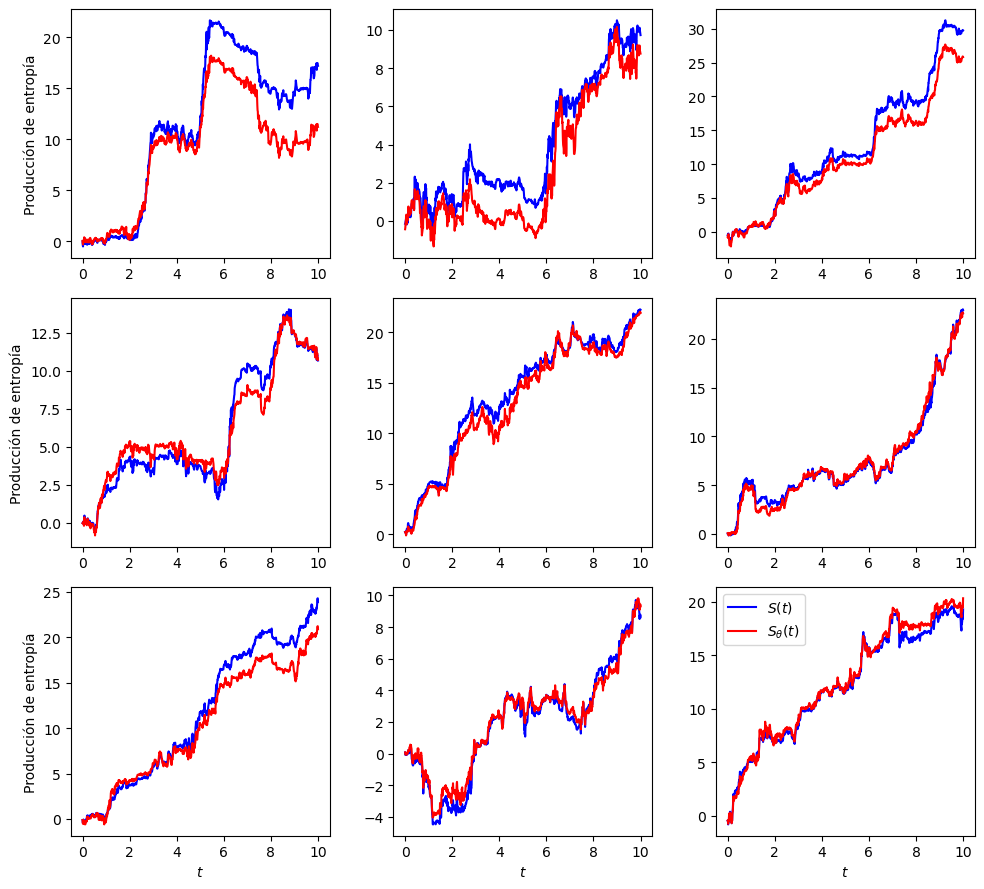

In [14]:
plt.figure(figsize=(10,9), dpi=100)
for i in range(9):
    plt.subplot(3, 3, i+1)
    indice = i
    entropia_ = entropia[indice]
    salida_ = salida[indice]
    plt.plot(ts, np.cumsum(entropia_), label='$S(t)$', color='b')
    plt.plot(ts, np.cumsum(salida_), label='$S_{\\theta}(t)$', color='r')
    if i >= 6:
        plt.xlabel('$t$')
    if i%3==0:
        plt.ylabel('Producción de entropía')
        
plt.legend()
plt.tight_layout()
plt.show()